# Where is the Signal? Variance Decomposition of the Forgetting Dataset

## Motivation

Our best regression model (without data leakage) explains only 3% of the variance in recall (R² = 0.03). As a classifier, we achieve AUC = 0.64. This notebook investigates where the signal actually is by decomposing variance at different levels: word identity, user identity, language combinations, and user-word pairs.

The key metric is the **between/within variance ratio**: if a grouping explains the data, variance between groups should be high relative to variance within groups. A ratio > 1 means the grouping explains more than the noise.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
df = pd.read_csv('data/learning_traces_sample.csv')
df['history_correct_rate'] = df['history_correct'] / df['history_seen']
print(f"Dataset: {df.shape[0]:,} sessions, {df['user_id'].nunique():,} users, {df['lexeme_id'].nunique():,} unique words")

Dataset: 499,436 sessions, 75,294 users, 11,227 unique words


## 1. User Profiling: Does Learner Behaviour Explain Recall?

We start by grouping users according to their learning behaviour (session frequency, total exposures, accuracy) to see whether the learner's profile alone can explain variance in recall. If user behaviour profiles capture signal, variance within each profile group should be lower than overall variance.

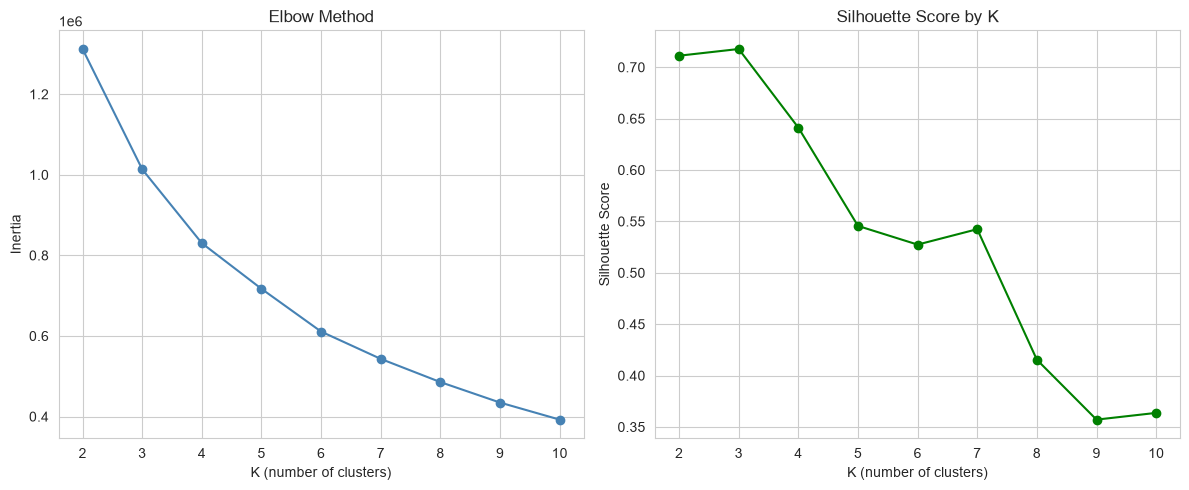

User profiles: 75,294 users
Best silhouette at K=3: 0.718


In [2]:
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

user_profiles = df.groupby('user_id').agg(
    avg_lag_days=('lag_days', 'mean'),
    avg_history_seen=('history_seen', 'mean'),
    avg_recall=('p_recall', 'mean'),
    total_sessions=('p_recall', 'count'),
    avg_correct_rate=('history_correct_rate', 'mean')
).reset_index()

cluster_features = ['avg_lag_days', 'avg_history_seen', 'avg_recall', 'total_sessions', 'avg_correct_rate']
scaler_users = RobustScaler()
X_users = scaler_users.fit_transform(user_profiles[cluster_features])

inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_users)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_users, labels, sample_size=10000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(K_range, inertias, marker='o', color='steelblue')
axes[0].set_xlabel('K (number of clusters)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, silhouettes, marker='o', color='green')
axes[1].set_xlabel('K (number of clusters)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')

plt.tight_layout()
plt.show()

print(f"User profiles: {user_profiles.shape[0]:,} users")
print(f"Best silhouette at K=3: {silhouettes[1]:.3f}")

In [3]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
user_profiles['cluster'] = kmeans.fit_predict(X_users)

cluster_summary = user_profiles.groupby('cluster')[cluster_features].mean().round(2)
cluster_summary['n_users'] = user_profiles.groupby('cluster').size().values
print(cluster_summary.to_string())

         avg_lag_days  avg_history_seen  avg_recall  total_sessions  avg_correct_rate  n_users
cluster                                                                                       
0                8.20              9.72        0.90            6.73              0.89    72449
1                5.60            524.19        0.88           75.57              0.90       54
2              140.59             10.13        0.86            2.81              0.89     2791


Three learner profiles emerge:
- **Cluster 0** (~72K users): Typical learners. Moderate session gaps (~8 days), moderate exposure, good recall (90%).
- **Cluster 1** (~54 users): Power users. Very high exposures (~524 avg) and many sessions. Intensive daily practice.
- **Cluster 2** (~2.8K users): Sporadic learners. Long gaps (~140 days), few sessions, lowest recall (86%).

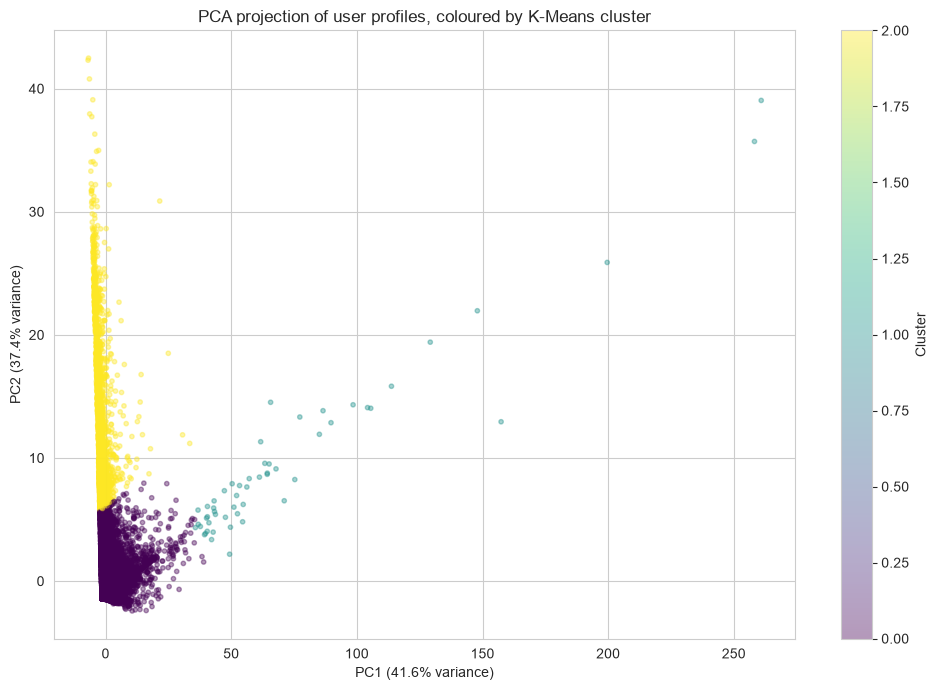

Explained variance: PC1=0.416, PC2=0.374
Total: 0.790


In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_users)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=user_profiles['cluster'], 
                     cmap='viridis', alpha=0.4, s=10)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title('PCA projection of user profiles, coloured by K-Means cluster')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}")
print(f"Total: {pca.explained_variance_ratio_.sum():.3f}")

In [5]:
df_with_clusters = df.merge(user_profiles[['user_id', 'cluster']], on='user_id', how='left')

for c in sorted(df_with_clusters['cluster'].dropna().unique()):
    subset = df_with_clusters[df_with_clusters['cluster'] == c]['p_recall']
    print(f"Cluster {int(c)}: mean={subset.mean():.3f}, std={subset.std():.3f}, "
          f"perfect={((subset==1.0).mean()*100):.1f}%, zero={((subset==0.0).mean()*100):.1f}%, "
          f"n={len(subset):,}")

print(f"\nOverall dataset: std={df['p_recall'].std():.3f}")

Cluster 0: mean=0.898, std=0.269, perfect=84.0%, zero=6.9%, n=487,500
Cluster 1: mean=0.769, std=0.394, perfect=71.4%, zero=18.8%, n=4,081
Cluster 2: mean=0.862, std=0.302, perfect=77.9%, zero=9.1%, n=7,855

Overall dataset: std=0.271


The standard deviation within each cluster (0.27-0.39) is no lower than the overall dataset (0.27). Knowing which type of learner someone is does not reduce our uncertainty about whether they will recall a specific word. The signal is not in the user profile.

We now decompose variance at different grouping levels to find where the signal actually lives.

## 2. Temporal and Practice Variables

Time since last practice and number of prior exposures are the two variables most correlated with recall in the EDA. Do they explain variance when used as groupings?

In [6]:
lag_bins = pd.cut(df['lag_days'], bins=[0, 0.04, 0.1, 1, 7, 30, 90, 500],
                  labels=['<1h', '1h-2h', '2h-1d', '1-7d', '7-30d', '30-90d', '90d+'])
practice_bins = pd.cut(df['history_seen'], bins=[0, 2, 5, 10, 20, 50, 15000],
                       labels=['1-2', '3-5', '6-10', '11-20', '21-50', '50+'])

lag_stats = df.groupby(lag_bins, observed=True).agg(
    mean_recall=('p_recall', 'mean'), std_recall=('p_recall', 'std'), n=('p_recall', 'count')
).reset_index()
between_lag = lag_stats['mean_recall'].var()
within_lag = (lag_stats['std_recall'] ** 2).mean()

prac_stats = df.groupby(practice_bins, observed=True).agg(
    mean_recall=('p_recall', 'mean'), std_recall=('p_recall', 'std'), n=('p_recall', 'count')
).reset_index()
between_prac = prac_stats['mean_recall'].var()
within_prac = (prac_stats['std_recall'] ** 2).mean()

combo_stats = df.groupby([lag_bins, practice_bins], observed=True).agg(
    mean_recall=('p_recall', 'mean'), std_recall=('p_recall', 'std'), n=('p_recall', 'count')
).reset_index()
combo_stats = combo_stats[combo_stats['n'] >= 30]
between_combo = combo_stats['mean_recall'].var()
within_combo = (combo_stats['std_recall'] ** 2).mean()

print(f"{'Grouping':<25} {'Between':<12} {'Within':<12} {'Ratio':<10}")
print("-" * 60)
print(f"{'Lag bins':<25} {between_lag:<12.4f} {within_lag:<12.4f} {between_lag/within_lag:<10.4f}")
print(f"{'Practice bins':<25} {between_prac:<12.4f} {within_prac:<12.4f} {between_prac/within_prac:<10.4f}")
print(f"{'Lag x Practice':<25} {between_combo:<12.4f} {within_combo:<12.4f} {between_combo/within_combo:<10.4f}")

Grouping                  Between      Within       Ratio     
------------------------------------------------------------
Lag bins                  0.0002       0.0794       0.0031    
Practice bins             0.0001       0.0750       0.0008    
Lag x Practice            0.0003       0.0798       0.0033    


All temporal ratios are below 0.01. Although average recall drops from 0.91 to 0.86 between short and long lags (confirmed in the EDA), this difference is tiny compared to the variance within each bin (std ~0.27 everywhere). Time and practice frequency do not meaningfully partition the data into predictable groups.

## 3. Word Identity

Does knowing which specific word it is help predict recall?

In [7]:
word_stats = df.groupby('lexeme_id').agg(
    mean_recall=('p_recall', 'mean'),
    std_recall=('p_recall', 'std'),
    n=('p_recall', 'count')
).reset_index()
word_stats = word_stats[word_stats['n'] >= 50]

between_words = word_stats['mean_recall'].var()
within_words = (word_stats['std_recall'] ** 2).mean()

print(f"Words with 50+ observations: {len(word_stats)}")
print(f"Variance BETWEEN words: {between_words:.4f}")
print(f"Variance WITHIN each word: {within_words:.4f}")
print(f"Ratio (between/within): {between_words/within_words:.4f}")

Words with 50+ observations: 1614
Variance BETWEEN words: 0.0021
Variance WITHIN each word: 0.0738
Ratio (between/within): 0.0287


## 4. User Identity

Does knowing who the user is help predict recall?

In [8]:
user_stats = df.groupby('user_id').agg(
    mean_recall=('p_recall', 'mean'),
    std_recall=('p_recall', 'std'),
    n=('p_recall', 'count')
).reset_index()
user_stats = user_stats[user_stats['n'] >= 10]

between_users = user_stats['mean_recall'].var()
within_users = (user_stats['std_recall'] ** 2).mean()

print(f"Users with 10+ sessions: {len(user_stats)}")
print(f"Variance BETWEEN users: {between_users:.4f}")
print(f"Variance WITHIN each user: {within_users:.4f}")
print(f"Ratio (between/within): {between_users/within_users:.4f}")

Users with 10+ sessions: 14061
Variance BETWEEN users: 0.0074
Variance WITHIN each user: 0.0722
Ratio (between/within): 0.1020


## 5. Word + Language (native language of the learner)

Does the combination of word and native language matter? For example, is "butterfly" harder for Spanish speakers than for Portuguese speakers?

In [9]:
word_lang_stats = df.groupby(['lexeme_id', 'ui_language']).agg(
    mean_recall=('p_recall', 'mean'),
    std_recall=('p_recall', 'std'),
    n=('p_recall', 'count')
).reset_index()
word_lang_stats = word_lang_stats[word_lang_stats['n'] >= 50]

between_wl = word_lang_stats['mean_recall'].var()
within_wl = (word_lang_stats['std_recall'] ** 2).mean()

print(f"Word + native language pairs with 50+ sessions: {len(word_lang_stats)}")
print(f"Variance BETWEEN pairs: {between_wl:.4f}")
print(f"Variance WITHIN each pair: {within_wl:.4f}")
print(f"Ratio (between/within): {between_wl/within_wl:.4f}")

Word + native language pairs with 50+ sessions: 1831
Variance BETWEEN pairs: 0.0021
Variance WITHIN each pair: 0.0725
Ratio (between/within): 0.0291


## 6. User + Word Pair

Does the specific combination of a user and a word have a consistent pattern? This captures the personal relationship between a learner and a specific vocabulary item.

In [10]:
pair_stats = df.groupby(['user_id', 'lexeme_id']).agg(
    mean_recall=('p_recall', 'mean'),
    std_recall=('p_recall', 'std'),
    n=('p_recall', 'count')
).reset_index()
pair_stats = pair_stats[pair_stats['n'] >= 5]

between_pairs = pair_stats['mean_recall'].var()
within_pairs = (pair_stats['std_recall'] ** 2).mean()

print(f"User-word pairs with 5+ sessions: {len(pair_stats)}")
print(f"Variance BETWEEN pairs: {between_pairs:.4f}")
print(f"Variance WITHIN each pair: {within_pairs:.4f}")
print(f"Ratio (between/within): {between_pairs/within_pairs:.4f}")

User-word pairs with 5+ sessions: 446
Variance BETWEEN pairs: 0.0361
Variance WITHIN each pair: 0.0609
Ratio (between/within): 0.5937


## 6.1 Is the Signal an Artifact?

Two potential biases could inflate the 0.59 ratio:

**Selection bias**: The 446 pairs with 5+ sessions belong to unusually active users. If the high ratio simply reflects that power users are more consistent, it would drop when we include less active pairs.

**Base rate bias**: 84% of the dataset is p_recall = 1.0. For a pair with n=5, the probability of all observations being 1.0 by chance alone is 0.84⁵ = 0.42. These "always perfect" pairs have within-variance = 0, pulling the average within down and inflating the ratio.

We test both: first by relaxing the session threshold (selection bias), then by examining how many pairs are trivially perfect and what the ratio looks like when we filter them out or restrict to only forgetting cases.

In [11]:
all_pair_stats = df.groupby(['user_id', 'lexeme_id']).agg(
    mean_recall=('p_recall', 'mean'),
    std_recall=('p_recall', 'std'),
    n=('p_recall', 'count')
).reset_index()

total_pairs = len(all_pair_stats)
single_session_pairs = (all_pair_stats['n'] == 1).sum()
print(f"Total user-word pairs: {total_pairs:,}")
print(f"Pairs with only 1 session: {single_session_pairs:,} ({single_session_pairs/total_pairs*100:.1f}%)")
print()

# Selection bias test: stability across thresholds
print("--- Selection bias test ---")
print(f"{'Min sessions':<15} {'Pairs':<10} {'Sessions covered':<20} {'Ratio':<10}")
print("-" * 55)
for min_n in [2, 3, 4, 5]:
    subset = all_pair_stats[all_pair_stats['n'] >= min_n]
    sessions_covered = subset['n'].sum()
    between = subset['mean_recall'].var()
    within = (subset['std_recall'] ** 2).mean()
    ratio = between / within
    print(f"{min_n:<15} {len(subset):<10,} {sessions_covered:<20,} {ratio:<10.4f}")

# Base rate bias test
print()
print("--- Base rate bias test ---")
pairs_5 = all_pair_stats[all_pair_stats['n'] >= 5]
always_perfect = (pairs_5['std_recall'] == 0).sum()
has_variance = (pairs_5['std_recall'] > 0).sum()
expected_by_chance = 0.84 ** 5

print(f"Pairs with n>=5: {len(pairs_5)}")
print(f"  Always perfect (std=0): {always_perfect} ({always_perfect/len(pairs_5)*100:.0f}%)")
print(f"  Expected by chance (0.84^5): {expected_by_chance*100:.0f}%")
print(f"  Has internal variance: {has_variance}")
print()

# Ratio with only variable pairs
var_pairs = pairs_5[pairs_5['std_recall'] > 0]
b_var = var_pairs['mean_recall'].var()
w_var = (var_pairs['std_recall'] ** 2).mean()

# Ratio on forgetting-only subset
df_forget = df[df['p_recall'] < 1.0]
pair_forget = df_forget.groupby(['user_id', 'lexeme_id']).agg(
    mean_recall=('p_recall', 'mean'),
    std_recall=('p_recall', 'std'),
    n=('p_recall', 'count')
).reset_index()
pair_forget_2 = pair_forget[pair_forget['n'] >= 2]
b_fgt = pair_forget_2['mean_recall'].var()
w_fgt = (pair_forget_2['std_recall'] ** 2).mean()

print(f"{'Filter':<35} {'Pairs':<10} {'Ratio':<10}")
print("-" * 55)
print(f"{'All pairs (n>=5)':<35} {len(pairs_5):<10} {0.5937:<10.4f}")
print(f"{'Only pairs with variance (n>=5)':<35} {len(var_pairs):<10} {b_var/w_var:<10.4f}")
print(f"{'Only forgetting cases (n>=2)':<35} {len(pair_forget_2):<10} {b_fgt/w_fgt:<10.4f}")

Total user-word pairs: 463,237
Pairs with only 1 session: 433,343 (93.5%)

--- Selection bias test ---
Min sessions    Pairs      Sessions covered     Ratio     
-------------------------------------------------------
2               29,894     66,093               0.5888    
3               4,310      14,925               0.5326    
4               1,124      5,367                0.4766    
5               446        2,655                0.5937    

--- Base rate bias test ---
Pairs with n>=5: 446
  Always perfect (std=0): 207 (46%)
  Expected by chance (0.84^5): 42%
  Has internal variance: 239

Filter                              Pairs      Ratio     
-------------------------------------------------------
All pairs (n>=5)                    446        0.5937    
Only pairs with variance (n>=5)     239        0.3321    
Only forgetting cases (n>=2)        1552       1.3096    


**Selection bias**: The ratio remains stable (0.48-0.59) from 29,894 pairs down to 446 pairs. Not an artifact of selecting power users.

**Base rate bias**: 46% of pairs with n>=5 are always perfect, close to the 42% expected by chance from the 84% base rate. These zero-variance pairs pull the average within down, partially inflating the 0.59 ratio. Filtering to only pairs with internal variance, the ratio drops to ~0.33. However, restricting to only forgetting cases (where there is real variance to explain), the ratio rises to 1.31.

**Conclusion**: The 0.59 ratio is partially inflated by the base rate, but the user+word signal is real and remains the strongest under any filter. It is the only grouping that exceeds 1.0 when evaluated on the subset where prediction matters (cases where the learner is at risk of forgetting).

## 7. Cohen's d: Within Same Profile, What Distinguishes Forgot vs Remembered?

Controlling for lag, exposure, and language, we compare the distributions of remaining variables between sessions where the learner forgot (p_recall = 0) and sessions where they remembered (p_recall = 1).

Cohen's d scale: |d| < 0.2 = negligible, 0.2-0.5 = small, 0.5-0.8 = medium, > 0.8 = large.

In [12]:
df_words = pd.read_csv('data/word_difficulty.csv')
df_analysis = df.merge(df_words[['lexeme_id', 'difficulty_rank_in_language']], on='lexeme_id', how='left')
df_analysis['difficulty_rank_in_language'] = df_analysis['difficulty_rank_in_language'].fillna(
    df_analysis['difficulty_rank_in_language'].median())

vowels_set = set('aeiouáéíóúàèìòùäëïöüâêîôû')
df_analysis['word_length'] = df_analysis['surface_form'].str.len()
df_analysis['vowel_ratio'] = df_analysis['surface_form'].apply(
    lambda w: sum(1 for c in w.lower() if c in vowels_set)) / df_analysis['word_length']

# Bin profiles
df_analysis['lag_bin'] = pd.cut(df_analysis['lag_days'], bins=[0, 0.01, 0.1, 1, 7, 30, 90, 500])
df_analysis['hist_bin'] = pd.cut(df_analysis['history_seen'], bins=[0, 2, 5, 10, 20, 50, 15000])

compare_vars = ['history_correct_rate', 'word_length', 'vowel_ratio', 'difficulty_rank_in_language']

results = []
for (lag, hist, lang), group in df_analysis.groupby(['lag_bin', 'hist_bin', 'learning_language']):
    remembered = group[group['p_recall'] == 1.0]
    forgot = group[group['p_recall'] == 0.0]
    if len(remembered) < 30 or len(forgot) < 30:
        continue
    for var in compare_vars:
        r_mean = remembered[var].mean()
        f_mean = forgot[var].mean()
        pooled_std = np.sqrt((remembered[var].std()**2 + forgot[var].std()**2) / 2)
        cohens_d = (f_mean - r_mean) / pooled_std if pooled_std > 0 else 0
        results.append({'variable': var, 'cohens_d': cohens_d})

results_df = pd.DataFrame(results)
print(f"Profile-variable comparisons: {len(results_df)}\n")
summary = results_df.groupby('variable')['cohens_d'].agg(['mean', 'count'])
summary['abs_mean'] = results_df.groupby('variable')['cohens_d'].apply(lambda x: x.abs().mean())
print(summary.round(4).to_string())

Profile-variable comparisons: 724

                               mean  count  abs_mean
variable                                            
difficulty_rank_in_language -0.3614    181    0.3650
history_correct_rate        -0.3170    181    0.3263
vowel_ratio                 -0.0024    181    0.0902
word_length                  0.0096    181    0.0986


## Summary

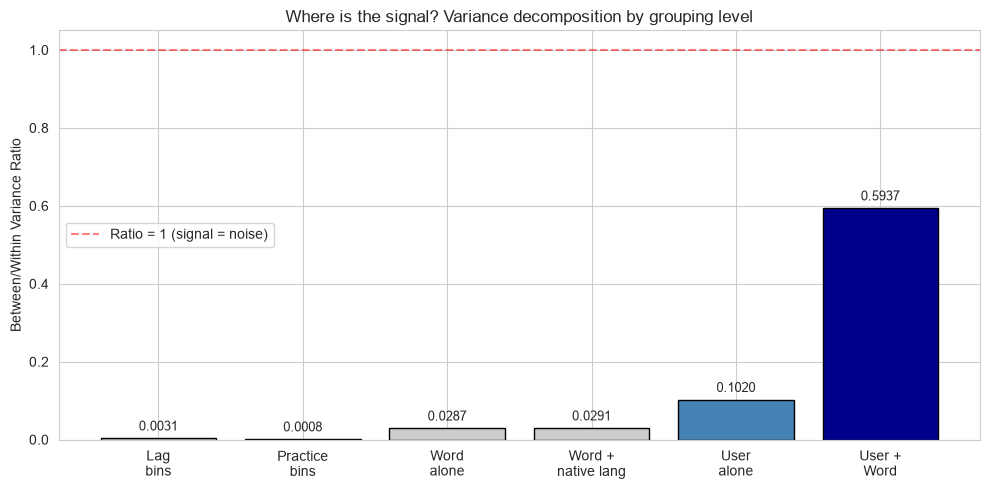

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

labels = ['Lag\nbins', 'Practice\nbins', 'Word\nalone', 'Word +\nnative lang', 'User\nalone', 'User +\nWord']
ratios = [0.0031, 0.0008, 0.0287, 0.0291, 0.1020, 0.5937]
colors = ['#eee', '#eee', '#ccc', '#ccc', 'steelblue', 'darkblue']

bars = ax.bar(labels, ratios, color=colors, edgecolor='black')
ax.set_ylabel('Between/Within Variance Ratio')
ax.set_title('Where is the signal? Variance decomposition by grouping level')
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Ratio = 1 (signal = noise)')
ax.legend()

for bar, val in zip(bars, ratios):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.4f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Conclusions and Future Work

### Findings

User profiling via K-Means clustering (section 1) does not reduce variance: std within clusters is the same as overall (0.27). Knowing the type of learner does not help predict their recall.

Temporal and practice variables (section 2) have ratios below 0.01. Despite being the features most correlated with recall, they do not partition the data into groups with meaningfully different outcomes.

Variance decomposition by grouping level:

| Grouping | Between/Within Ratio | Interpretation |
|---|---|---|
| Lag bins | < 0.01 | Time since last practice explains almost nothing |
| Practice bins | < 0.01 | Number of exposures explains almost nothing |
| Word alone | 0.03 | The word itself explains almost nothing |
| Word + native language | 0.03 | Adding the learner's native language does not help |
| User alone | 0.10 | Some users have better memory than others |
| User + Word | 0.59 (0.33 corrected) | The personal relationship between a user and a word is where most signal lives |

The 0.59 ratio is partially inflated by the 84% base rate of perfect recall (section 6.1). Correcting for this, the ratio is ~0.33, still the strongest of all groupings. On the forgetting-only subset, the ratio exceeds 1.0 (1.31), confirming the signal is real.

Within same profiles (Cohen's d):
- `difficulty_rank_in_language`: d = 0.36 (small effect)
- `history_correct_rate`: d = 0.32 (small effect)
- `word_length`, `vowel_ratio`: d < 0.1 (negligible)

### Implications

The signal in this dataset is fundamentally **personal and item-specific**. It is not about "hard words" or "bad learners" in general. It is about the specific history between one user and one word. This is exactly what personalised spaced repetition systems are designed to exploit.

### Future Work

1. **User memory score**: Compute a rolling average of past recall per user (before each session) as a feature. The between-user ratio of 0.10 suggests this would add signal.
2. **User-word pair history**: With a larger dataset (the full 13M sessions), enough repetitions per user-word pair would allow building pair-specific features.
3. **Temporal patterns**: The dataset comes from a 13-day window. A longitudinal dataset tracking users over months would allow modelling individual learning curves.
4. **Cross-lingual similarity is not a path forward**: Word + native language has the same ratio as word alone (0.03). The learner's native language does not meaningfully interact with word-level difficulty in this dataset.